In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)


# dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = False, #True
)
dataset.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model = MixedFCTemporalModel(
    n_classes=4, #1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training
n_epochs = 500
        
trainer = Trainer(
    dataset,
    model,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=False, #True,
    regression_bounds = None,#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [2]:
trainer.summary()   
trainer.train(n_epochs)
print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.35 │                     26.81 │
│             1             │                      1.30 │                     43.36 │
│             3             │                      1.21 │                     49.04 │
│             4             │                      1.21 │                     50.03 │
│             5             │                      1.19 │                     50.08 │
│             6             │                      1.18 │                     50.15 │
│             12            │                      1.17 │                     50.99 │
│             20    

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:265: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.5961, device='cuda:0'),
 'CohenKappa': tensor(0.4195, device='cuda:0')}

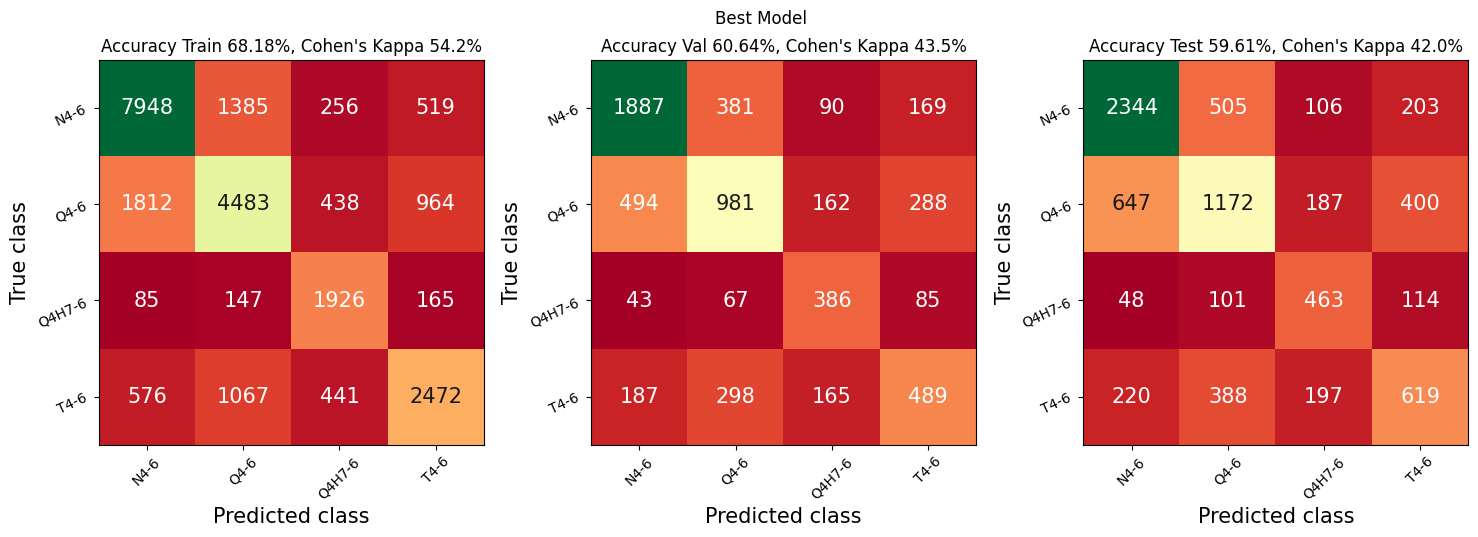

In [3]:
trainer.test("best")

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)

# dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset2 = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = True
)
dataset2.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model2 = MixedFCTemporalModel(
    n_classes= 1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset2.length_serie,
    input_size=dataset2.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training
n_epochs = 500
        
trainer2 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=True,        
    use_class_weights=False,
    regression_bounds = torch.Tensor([0.5,1.5,2.5]).to("cuda") #torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

trainer2.summary()   

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
N4-6: 0.61 Q4-6: 0.80 Q4H7-6: 2.66 T4-6: 1.35 

,Total,N4-6,Q4-6,Q4H7-6,T4-6
Train,24684,10108,7697,2323,4556
Validation,6172,2527,1925,581,1139
Test,7714,3158,2406,726,1424
Total,38570,15793,12028,3630,7119


╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.60 │                     40.99 │
│             5             │                      1.24 │                     41.61 │
│             7             │                      1.20 │                     43.05 │
│             8             │                      1.19 │                     45.76 │
│             11            │                      1.21 │                     48.12 │
│             12            │                      1.17 │                     48.85 │
│             13            │                      1.12 │                     49.63 │
│             14            │                      1.14 │                     49.76 │
│             15            │                      1.1

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.5097, device='cuda:0'),
 'CohenKappa': tensor(0.2832, device='cuda:0')}

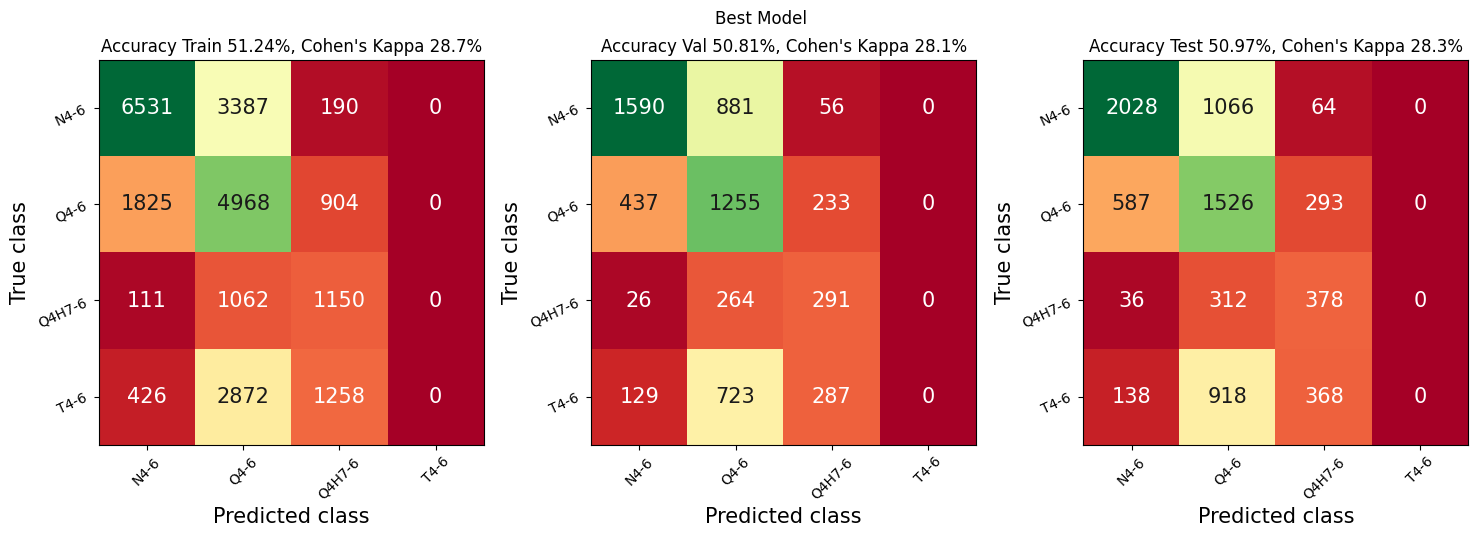

In [9]:
trainer2.train(n_epochs)
trainer2.test("best")

In [ ]:
x, y = trainer2.dataset.test_batch(True, to_cuda=True)
y_pred = trainer2.model(torch.Tensor(x))
print(y_pred)

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.76 │                     49.87 │
│            499            │                      0.62 │                           │
╰───────────────────────────┴───────────────────────────┴───────────────────────────╯


D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.4999, device='cuda:0'),
 'CohenKappa': tensor(0.2094, device='cuda:0')}

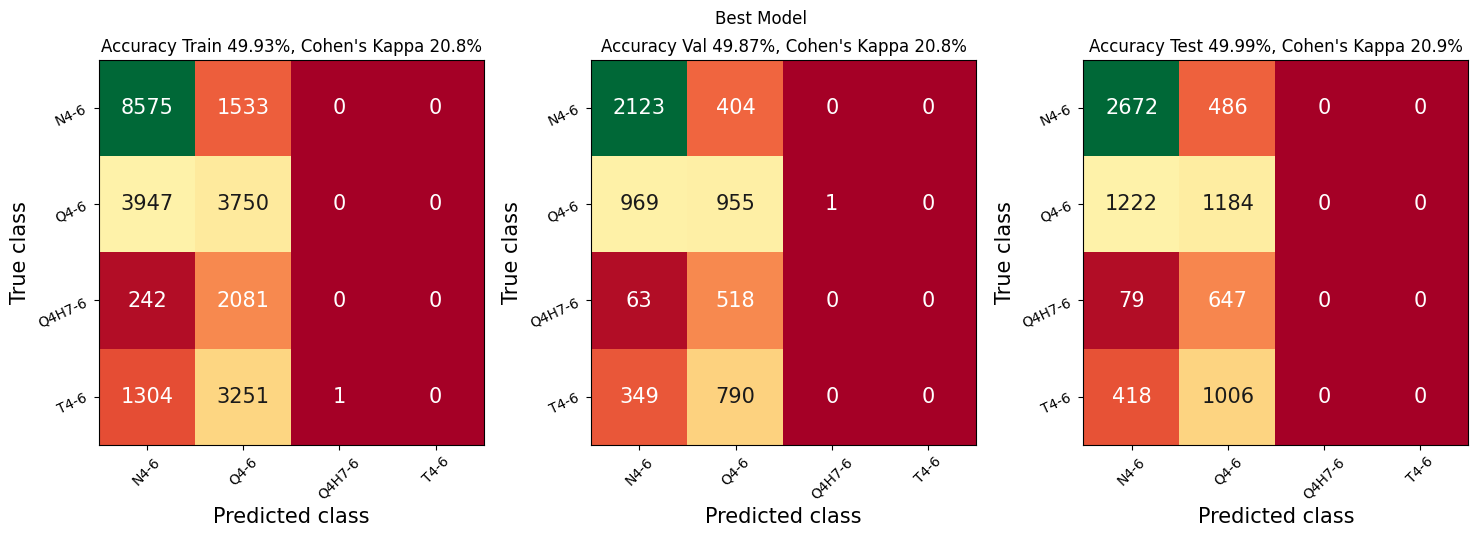

In [10]:
trainer3 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=True,        
    use_class_weights=True,
    regression_bounds = torch.Tensor([0.5,1.5,2.5]).to("cuda") #torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

trainer3.summary()
trainer3.train(n_epochs)
trainer3.test("best")  

In [9]:
from progress_table import ProgressTable
from copy import deepcopy
from torchmetrics.classification import Accuracy, CohenKappa, ConfusionMatrix
from torch import tensor

if trainer2.scheduler is None:
    trainer2.scheduler = trainer2.default_scheduler()(T_max=n_epochs)
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())

x, y = trainer2.dataset.train_batch(True, to_cuda=True)
batch_size = len(x) if trainer2.batch_size is None else trainer2.batch_size

current_best = 0
xval, yval = trainer2.dataset.val_batch(True, to_cuda=True)
table = ProgressTable(
    num_decimal_places=2,
    print_header_every_n_rows=15,
    # print_header_every_n_rows=15,
    pbar_show_progress=True,
    pbar_style="square",
    default_column_width=25,
)

table.add_column("Epoch")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")

for e in table(
    range(n_epochs),
    total=n_epochs,
    description="Epoch",
    show_eta=True,
):
    idx = torch.randperm(x.shape[0], device=x.device)
    x = x[idx]
    y = y[idx]

    trainer2.model.train()
    for i in range(0, len(x), batch_size):
        trainer2.optim.zero_grad()
        x_batch = x[i : i + batch_size]
        if trainer2.is_regression:
            y_batch = y[i : i + batch_size].type(torch.FloatTensor).to(trainer2.device)
        else:
            y_batch = y[i : i + batch_size].type(torch.LongTensor).to(trainer2.device)
        # Take batch size:

        with torch.autocast("cuda"): #torch.cuda.amp.autocast()
            y_pred = trainer2.model(x_batch)
            loss = trainer2.criterion(y_pred, y_batch, weight=trainer2.dataset.weights)
            
        
        loss.backward()
        trainer2.optim.step()
    print(loss)
    thisParam = trainer2.model.final_layer.parameters()
    for p in thisParam:
        print(p.grad)

    if trainer2.scheduler:
        trainer2.scheduler.step()
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # if e % 10 == 0:
    #     if trainer2.is_regression:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.FloatTensor).to(trainer2.device))
    #     else:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.LongTensor).to(trainer2.device))
    #     if scores[trainer2._store_best] > current_best:
    #         current_best = scores[trainer2._store_best]
    #         trainer2._best_state_dict = deepcopy(trainer2.model.state_dict())
    #         if True:
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")

    #         table.next_row()

TypeError: myMSELoss.__call__() got an unexpected keyword argument 'weight'